In [1]:
%matplotlib inline
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from scipy import stats
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
from scipy.stats import entropy
from scipy.spatial import distance

In [2]:
"""
You can start the code from here
"""
#Import the actual data
df_biofilm_filtered = pd.read_csv('Figurewise raw data/Biofilm_filtered.csv', index_col = 0)
df_biofilm_filtered.head()

,3,8,28,32,42,64,70,78,100,108,...,t_27_enrichment,t_39_enrichment,t_45_enrichment,t_63_enrichment,t_73_enrichment,t_81_enrichment,t_99_enrichment,t_107_enrichment,t_115_enrichment,t_137_enrichment
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0,1,7,3,1,0,3,1,3,3,...,0.301030,0.602060,0.301030,0.602060,1.255273,1.146128,0.903090,0.000000,0.000000,0.000000
ACTGGAGAGACGCTCCAAGT,0,5,1,0,2,0,1,2,0,0,...,0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000
GTTTTTAAATGTGTGCCCGG,1,4,1,3,9,0,4,0,0,0,...,-0.301030,-0.301030,0.397940,0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030
GTACTAAATTGATGCCCATT,10,0,0,0,0,0,0,2,3,0,...,-0.740363,-1.041393,-1.041393,-0.740363,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393
GGCCAAAGTACCTGTTAAAT,7,4,4,4,6,10,5,9,3,4,...,-0.903090,-0.425969,0.096910,-0.903090,-0.903090,-0.425969,-0.903090,-0.903090,-0.425969,-0.903090


In [3]:
"""Really really good code!!"""

import numpy as np
import pandas as pd
import os

# Setup
Npo = 4.3*10**7
Npmax = 10**10
Ndmax = 3.2*10**6
tdp = 34
up = np.log(2)/tdp
dt = 10
tdd_list = [70]  #doubling time disc

#We run the simulation for a range of binding constants
kb_list = [10**(-8.095)]

steps = int(1440/dt)
num_discs = 18

# Donor distribution
donor_f = df_biofilm_filtered['t_3_f']

Num_uniq_barcodes = []

discname_list = []
for i in range(num_discs):
    discname_list.append('Disc_'+str(i))

df_founding_population = {}



for kb in kb_list:
    for tdd in tdd_list:
        um = np.log(2)/tdd
        # Initialize populations
        df_planktonic = np.random.multinomial(Npo, donor_f).astype(np.int32)
        df_discs = np.array([np.random.poisson(df_planktonic * kb) for _ in range(num_discs)])
        df_discs_binding = np.array([np.random.poisson(df_planktonic * kb) for _ in range(num_discs)])
        
        # Precompute capacity ratios to avoid repeated .sum()
        for t in range(steps):
            Np = df_planktonic.sum()
            #We estimate the carrying capacity in biofilms
            cap_p = max(1 - Np / Npmax, 0)
            if steps * 10 >= 60:
                #We model the growtn in the planktonic as a poisson (correct approx for small step size)
                growth_p = np.random.poisson(df_planktonic * up * cap_p * dt)
                df_planktonic += growth_p
        
            for d in range(num_discs):
                Nd = df_discs[d].sum()
                cap_d = max(1 - Nd / Ndmax, 0)
                #We model the growtn on the disc using poisson (correct approx for small step size)
                growth_d = np.random.poisson(df_discs[d] * um * cap_d * dt)
                #We model the growtn in the planktonic using a poisson distribution (correct approx for small step size)
                
                #We model the binding on disc using a poisson distribution (correct approx for small step size)
                binding = np.random.poisson(df_planktonic * kb * cap_d *dt)
                df_discs[d] += growth_d + binding
                df_discs_binding[d] += binding
        
        # Save once at the end
        if not os.path.exists('Simulation_final'):
            os.makedirs('Simulation_final')
        
        pd.concat([df_biofilm_filtered[['t_3_f']],pd.DataFrame(df_discs.transpose(), columns=discname_list,\
                                                       index=df_biofilm_filtered.index.values)], axis = 1)\
        .sort_values('t_3_f', ascending = 0).to_csv(f'Simulation_final/run_{round(np.log10(kb),3)}_{tdd}_2.csv', index=False)
        df_founding_population[round(np.log10(kb),3)] = df_discs_binding.sum()
        # Summary
        print(f"Completed simulation with kb={round(np.log10(kb),3)}, tdd={tdd}")
        print("Final unique barcodes per disc:", [np.sum(d > 0) for d in df_discs])
        Num_uniq_barcodes.append([np.sum(d > 0) for d in df_discs][0])


KeyboardInterrupt



In [3]:

#Read the df_predict the prediction for the best simulation
df_predict = pd.read_csv(f'Simulation_final/run_-8.095_70_2.csv')

#Results for df_predict
df_predict

,t_3_f,Disc_0,Disc_1,Disc_2,Disc_3,Disc_4,Disc_5,Disc_6,Disc_7,Disc_8,Disc_9,Disc_10,Disc_11,Disc_12,Disc_13,Disc_14,Disc_15,Disc_16,Disc_17
0,0.008848,23479,31123,21088,34689,40453,25970,24541,28200,23434,37300,32443,37317,29634,32912,33184,23933,22951,30472
1,0.006956,16355,29085,24807,19845,28552,28956,22926,23176,18287,22385,17458,29695,25588,21038,26214,16777,19710,15775
2,0.004340,18931,9027,14711,12667,16383,11711,13494,14764,17393,10253,13124,22276,17509,11241,13949,10337,9680,12495
3,0.004300,11495,10588,11108,12673,16567,13442,13220,10056,14284,14837,15518,13790,11424,15595,12937,17342,11689,11506
4,0.004112,23437,15921,15424,9277,12813,10302,16583,16134,8270,13027,14205,13716,16981,11442,16885,11762,10238,13813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169316,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
169317,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
169318,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
169319,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:

sample_dict = {'Flask_A':['4'], 'Flask_B':['5'], 'Flask_C':['6'], 'Flask_D':['7'],\
               'Planktonic_A':['8'], 'Planktonic_B':['9'], 'Planktonic_C':['10'], 'Planktonic_D':['11'],\
               'Disc_A': ['12','13','14'],'Disc_B':['15','16','17'],'Disc_C':['18','19','20'],'Disc_D':['21','22','23']}

print(distance.braycurtis(df_biofilm_filtered.t_3_f,\
            df_biofilm_filtered[['12','13','14','15','16','17','13','14','15','16','17','18','19','20','21','22','23']].sum(axis = 1)/\
df_biofilm_filtered[['12','13','14','15','16','17','13','14','15','16','17','18','19','20','21','22','23']].sum(axis = 1).sum().sum()))

distance.braycurtis(df_biofilm_filtered.t_3_f,\
            df_biofilm_filtered[['8']].sum(axis = 1)/\
df_biofilm_filtered[['8']].sum(axis = 1).sum().sum())

0.5661588235294119


np.float64(0.4341480000000001)

In [7]:
entropy(df_biofilm_filtered[['12','13','14']].sum(axis = 1)/\
df_biofilm_filtered[['12','13','14']].sum(axis = 1).sum().sum())

np.float64(9.407830653095886)

In [8]:
entropy(df_predict[['Disc_0']].sum(axis = 1)/df_predict[['Disc_0']].sum(axis = 1).sum())

np.float64(8.939955838213304)

In [14]:
#parameters for the selection
# Setup
Nd0 = 5.4*10**5
Npo = 1.3*10**7
Npmax = 10**10
Ndmax = 3.2*10**6
tdp = 34
up = np.log(2)/tdp
dt = 10
tdd = 70  #doubling time disc
kb = 10**(-8.095)
steps = int(1440/dt)

migration_rate_list = np.concatenate((np.array([0]), 10**np.arange(-9, -3, 0.5)))

um = np.log(2)/tdd

num_discs = 18

discname_list = []
for i in range(num_discs):
    discname_list.append('Disc_'+str(i))

for migration_rate in migration_rate_list:
    num_discs = 18
    print(migration_rate)
    df_biofilm_evolved = df_predict.copy()
    df_biofilm_evolved['Disc_0_norm'] = np.random.multinomial(250000,df_biofilm_evolved['Disc_0']/df_biofilm_evolved['Disc_0'].sum())
    Shannon_entropy_p = [entropy(df_biofilm_evolved.t_3_f)]
    Shannon_entropy_d = [entropy(df_biofilm_evolved.Disc_0_norm/250000)]

    bray_curtis_d = [distance.braycurtis(df_biofilm_evolved.t_3_f,\
                                        df_biofilm_evolved.Disc_0_norm/250000)]
    bray_curtis_p = [distance.braycurtis(df_biofilm_filtered['t_3_f'].replace(np.nan,0),\
                                            df_biofilm_filtered['t_8_f'].replace(np.nan,0))]
    
    for cycle in range(0,15):
        print(cycle)
        if (cycle%3 == 0):
           num_discs = num_discs - 3 
        
        discname_list = []
        for i in range(num_discs):
            discname_list.append('Disc_'+str(i))
        
        df_biofilm_evolved['Biofilm_Pop'] = df_biofilm_evolved[discname_list].sum(axis = 1)
        df_biofilm_evolved['Biofilm_f'] = df_biofilm_evolved['Biofilm_Pop']/df_biofilm_evolved.Biofilm_Pop.sum()
        
        #We get the fractions associated with the distrbution
        df_fractions = df_biofilm_evolved[discname_list]/df_biofilm_evolved[discname_list].sum()
        df_planktonic = np.random.multinomial(Npo, df_biofilm_evolved['Biofilm_f']).astype(np.int32)
        
        subsampled_data = {}
        for col in discname_list:
            # 1. Extract the probabilities for the current disc
            pvals = df_biofilm_evolved[col].values
        
            # 2. Normalize to ensure they sum exactly to 1.0 
            # (Important to avoid errors from floating point rounding)
            pvals = pvals / pvals.sum()
            
            # 3. Perform the multinomial draw
            subsampled_data[col] = np.random.multinomial(Nd0, pvals)
        # 4. Convert back to a DataFrame with the same indices as your input
        df_discs = pd.DataFrame(subsampled_data, index=df_predict.index)
        df_discs = df_discs.transpose().values
        for t in range(steps):
            Np = df_planktonic.sum()
            #We estimate the carrying capacity in biofilms
            cap_p = max(1 - Np / Npmax, 0)
            if steps * 10 >= 60:
            #We model the growtn in the planktonic as a poisson (correct approx for small step size)
                growth_p = np.random.poisson(df_planktonic * up * cap_p * dt)
                df_planktonic += growth_p
            for d in range(num_discs):
                Nd = df_discs[d].sum()
                cap_d = max(1 - Nd / Ndmax, 0)
                #We model the growtn on the disc using poisson (correct approx for small step size)
                growth_d = np.random.poisson(df_discs[d] * um * cap_d * dt)
                #We model the growtn in the planktonic using a poisson distribution (correct approx for small step size)
                   
                #We model the binding on disc using a poisson distribution (correct approx for small step size)
                binding = np.random.poisson(df_planktonic * kb * cap_d *dt)
                migration = np.random.poisson(df_planktonic * migration_rate * cap_d *dt)
                df_discs[d] += growth_d + binding + migration
                
                #We remove the bound cells from the planktonic
                df_planktonic -= binding # Conservation of cells
                df_planktonic = np.maximum(df_planktonic, 0)
                
        df_biofilm_evolved = pd.concat([pd.DataFrame(df_planktonic,index=df_predict.index.values).rename(columns = {0:'Planktonic'}),\
                                        pd.DataFrame(df_discs.transpose(), columns=discname_list,\
                                                               index=df_predict.index.values)], axis = 1)\
                .sort_values('Planktonic', ascending = 0)
        df_biofilm_evolved['Planktonic_norm'] = np.random.multinomial(250000,df_biofilm_evolved.Planktonic/df_biofilm_evolved.Planktonic.sum())
        Shannon_entropy_p.append(entropy(df_biofilm_evolved['Planktonic_norm']/250000))
        bray_curtis_p.append(distance.braycurtis(df_predict.t_3_f, df_biofilm_evolved.Planktonic_norm/250000))
       
        
        df_biofilm_evolved['Disc_0_norm'] = np.random.multinomial(250000,df_biofilm_evolved['Disc_0']/df_biofilm_evolved['Disc_0'].sum())
        Shannon_entropy_d.append(entropy(df_biofilm_evolved.Disc_0_norm/250000))
        bray_curtis_d.append(distance.braycurtis(df_predict.t_3_f, df_biofilm_evolved.Disc_0_norm/250000))

    df_data = pd.DataFrame({'Planktonic':Shannon_entropy_p, 'Disc':Shannon_entropy_d})
    df_data_dist = pd.DataFrame({'Planktonic':bray_curtis_p, 'Disc':bray_curtis_d})
    
    df_data.to_csv('Simulation_final/Temp/Shannon_Pred_Temp_'+str(np.log10(migration_rate))+'.csv')
    df_data_dist.to_csv('Simulation_final/Temp/Distance_Pred_Temp_'+str(np.log10(migration_rate))+'.csv')

0.0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14


C:\Users\achoudhu\AppData\Local\Temp\ipykernel_23036\2136904481.py:107: RuntimeWarning: divide by zero encountered in log10
  df_data.to_csv('Simulation_final/Temp/Shannon_Pred_Temp_'+str(np.log10(migration_rate))+'.csv')
C:\Users\achoudhu\AppData\Local\Temp\ipykernel_23036\2136904481.py:108: RuntimeWarning: divide by zero encountered in log10
  df_data_dist.to_csv('Simulation_final/Temp/Distance_Pred_Temp_'+str(np.log10(migration_rate))+'.csv')


1e-09
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
3.1622776601683795e-09
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
1e-08
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
3.162277660168379e-08
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
1e-07
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
3.162277660168379e-07
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
1e-06
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
3.162277660168379e-06
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
1e-05
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
3.1622776601683795e-05
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
0.0001
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
0.00031622776601683794
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14


In [15]:
df_data.to_csv('Simulation_final/Temp/Shannon_Pred_Temp_'+str(np.log(migration_rate))+'.csv')

In [21]:
(5.4e6-5.4e5)*18

87480000.0

In [31]:
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
from scipy.stats import entropy
from scipy.spatial import distance

def run_simulation(migration_rate, rep):
    # Reproducible but unique seed per job
    """
    The following code is to run temporal simulation in biofilms with varying migration rates
    
    """
    
    np.random.seed(rep + int(migration_rate * 1e12))

    # Parameters
    Nd0 = 5.4e5
    Npo = 1.3e7
    Npmax = 1e10
    Ndmax = 3.2e6
    tdp = 34
    up = np.log(2) / tdp
    dt = 10
    tdd = 70
    kb = 10**(-8.095)
    steps = int(1440 / dt)
    um = np.log(2) / tdd

    num_discs = 18

    # Initial dataframe
    df_biofilm_evolved = df_predict.copy()

    df_biofilm_evolved['Disc_0_norm'] = np.random.multinomial(
        250000,
        df_biofilm_evolved['Disc_0'] / df_biofilm_evolved['Disc_0'].sum()
    )

    Shannon_entropy_p = [entropy(df_biofilm_evolved.t_3_f)]
    Shannon_entropy_d = [entropy(df_biofilm_evolved.Disc_0_norm / 250000)]

    bray_curtis_d = [distance.braycurtis(
        df_biofilm_evolved.t_3_f,
        df_biofilm_evolved.Disc_0_norm / 250000
    )]

    bray_curtis_p = [distance.braycurtis(
        df_biofilm_filtered['t_3_f'].fillna(0),
        df_biofilm_filtered['t_8_f'].fillna(0)
    )]

    # =========================
    # MAIN SIMULATION LOOP
    # =========================
    for cycle in range(15):
        print(cycle)
        if cycle % 3 == 0:
            num_discs -= 3

        discname_list = [f'Disc_{i}' for i in range(num_discs)]

        # ---- Biofilm fractions ----
        biofilm_pop = df_biofilm_evolved[discname_list].sum(axis=1)
        
        total_pop = biofilm_pop.sum()
        
        if total_pop > 0:
            biofilm_f = biofilm_pop / total_pop
        else:
            biofilm_f = np.zeros_like(biofilm_pop)

        # ---- Planktonic sampling ----
        #We assume that 1/10th of the biofilm population is released into the planktonic population
        df_planktonic = np.random.multinomial(total_pop/10, biofilm_f).astype(np.int32)

        # ---- Subsample discs ----
        subsampled = []
        for col in discname_list:
            pvals = df_biofilm_evolved[col].values
            total = pvals.sum()
            if total > 0:
                pvals = pvals / total
            subsampled.append(np.random.multinomial(Nd0, pvals))

        df_discs = np.array(subsampled)  # shape: (num_discs, num_strains)

        # =========================
        # TIME LOOP (VECTORISED)
        # =========================
        for t in range(steps):

            # ---- Planktonic growth ----
            Np = df_planktonic.sum()
            cap_p = max(1 - Np / Npmax, 0)

            df_planktonic += np.random.poisson(
                df_planktonic * up * cap_p * dt
            )

            # ---- Disc capacities ----
            Nd = df_discs.sum(axis=1)  # per disc
            cap_d = np.maximum(1 - Nd / Ndmax, 0)
            cap_d_expanded = cap_d[:, None]

            # ---- Vectorised processes ----
            growth_d = np.random.poisson(df_discs * um * cap_d_expanded * dt)

            binding = np.random.poisson(
                df_planktonic * kb * cap_d_expanded * dt
            )

            migration = np.random.poisson(
                df_planktonic * migration_rate * cap_d_expanded * dt
            )

            # ---- Update discs ----
            df_discs += growth_d + binding + migration

            # ---- Remove bound cells from planktonic ----
            total_binding = binding.sum(axis=0)
            total_binding = np.minimum(total_binding, df_planktonic)

            df_planktonic -= total_binding
            df_planktonic = np.maximum(df_planktonic, 0)

        # =========================
        # REBUILD DATAFRAME
        # =========================
        df_biofilm_evolved = pd.concat([
            pd.DataFrame(df_planktonic, index=df_predict.index)
              .rename(columns={0: 'Planktonic'}),
            pd.DataFrame(df_discs.T,
                         columns=discname_list,
                         index=df_predict.index)
        ], axis=1)

        # ---- Metrics ----
        df_biofilm_evolved['Planktonic_norm'] = np.random.multinomial(
            250000,
            df_biofilm_evolved.Planktonic /
            df_biofilm_evolved.Planktonic.sum()
        )

        Shannon_entropy_p.append(
            entropy(df_biofilm_evolved['Planktonic_norm'] / 250000)
        )

        bray_curtis_p.append(
            distance.braycurtis(
                df_predict.t_3_f,
                df_biofilm_evolved.Planktonic_norm / 250000
            )
        )

        df_biofilm_evolved['Disc_0_norm'] = np.random.multinomial(
            250000,
            df_biofilm_evolved['Disc_0'] /
            df_biofilm_evolved['Disc_0'].sum()
        )

        Shannon_entropy_d.append(
            entropy(df_biofilm_evolved.Disc_0_norm / 250000)
        )

        bray_curtis_d.append(
            distance.braycurtis(
                df_predict.t_3_f,
                df_biofilm_evolved.Disc_0_norm / 250000
            )
        )

    # =========================
    # OUTPUT
    # =========================
    df_data = pd.DataFrame({
        'Planktonic': Shannon_entropy_p,
        'Disc': Shannon_entropy_d,
        'migration_rate': migration_rate,
        'replicate': rep,
        'cycle': range(len(Shannon_entropy_p))
    })

    df_data_dist = pd.DataFrame({
        'Planktonic': bray_curtis_p,
        'Disc': bray_curtis_d,
        'migration_rate': migration_rate,
        'replicate': rep,
        'cycle': range(len(bray_curtis_p))
    })
    
    return df_data, df_data_dist

In [32]:

#migration_rate_list = np.concatenate((np.array([0]), 10**np.arange(-9, -3, 0.5)))
migration_rate_list = np.concatenate((np.array([0]), 10**np.arange(-9, -3, 0.5)))

jobs = [(m, r) for m in migration_rate_list for r in range(10)]

results = Parallel(n_jobs=-1)(
    delayed(run_simulation)(m, r) for m, r in jobs
)

final_df = pd.concat([r[0] for r in results], ignore_index=True)
final_df_dist = pd.concat([r[1] for r in results], ignore_index=True)

final_df.to_csv('Simulation_final/Temp/Shannon_all.csv', index=False)
final_df_dist.to_csv('Simulation_final/Temp/Distance_all.csv', index=False)

In [59]:
final_df.to_csv('Simulation_final/Temp/Shannon_all.csv', index=False)
final_df_dist.to_csv('Simulation_final/Temp/Distance_all.csv', index=False)

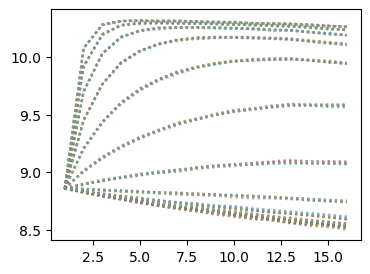

In [11]:
# Create a new figure for the plot
plt.figure(figsize=[4, 3])

#--- Plot 0: Simulated data for how the population dynamics should look like ---
df_simulation = pd.read_csv('Simulation_final/Temp/Shannon_all.csv')

for rate in df_simulation.migration_rate.drop_duplicates():
    for replicate in range(10):
        df = df_simulation.loc[(df_simulation.migration_rate == rate) & (df_simulation.replicate == replicate)]
        plt.plot(df.cycle+1, df.Disc,':', alpha = 0.5, label = '')

In [3]:
df_predict = pd.read_csv(f'Simulation_final/run_-8.095_70_2.csv')
df_predict

,t_3_f,Disc_0,Disc_1,Disc_2,Disc_3,Disc_4,Disc_5,Disc_6,Disc_7,Disc_8,Disc_9,Disc_10,Disc_11,Disc_12,Disc_13,Disc_14,Disc_15,Disc_16,Disc_17
0,0.008848,23479,31123,21088,34689,40453,25970,24541,28200,23434,37300,32443,37317,29634,32912,33184,23933,22951,30472
1,0.006956,16355,29085,24807,19845,28552,28956,22926,23176,18287,22385,17458,29695,25588,21038,26214,16777,19710,15775
2,0.004340,18931,9027,14711,12667,16383,11711,13494,14764,17393,10253,13124,22276,17509,11241,13949,10337,9680,12495
3,0.004300,11495,10588,11108,12673,16567,13442,13220,10056,14284,14837,15518,13790,11424,15595,12937,17342,11689,11506
4,0.004112,23437,15921,15424,9277,12813,10302,16583,16134,8270,13027,14205,13716,16981,11442,16885,11762,10238,13813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169316,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
169317,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
169318,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
169319,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
from scipy.stats import entropy
from scipy.spatial import distance

def run_simulation_amk(migration_rate, rep):
    # Reproducible but unique seed per job
    
    seed = (rep + int(migration_rate * 1e12)) % (2**32 - 1)
    np.random.seed(seed)

    
    # Parameters
    Nd0 = 5.4e5
    Npo = 1.3e7
    Npmax = 1e10
    Ndmax = 3.2e6
    tdp = 34
    up = np.log(2) / tdp
    dt = 10
    tdd = 70
    kb = 10**(-8.095)
    steps = int(1440 / dt)
    um = np.log(2) / tdd
    #antibiotic_cycles = {1, 4, 7, 10, 13}
    antibiotic_cycles = {0, 3, 6, 9, 12}
    
    DISC_SURVIVORS = 18900
    PLANKTONIC_SURVIVORS = 173000

    num_discs = 18

    # Initial dataframe
    df_biofilm_evolved = df_predict.copy()

    df_biofilm_evolved['Disc_0_norm'] = np.random.multinomial(
        250000,
        df_biofilm_evolved['Disc_0'] / df_biofilm_evolved['Disc_0'].sum()
    )

    Shannon_entropy_p = [entropy(df_biofilm_evolved.t_3_f)]
    Shannon_entropy_d = [entropy(df_biofilm_evolved.Disc_0_norm / 250000)]

    bray_curtis_d = [distance.braycurtis(
        df_biofilm_evolved.t_3_f,
        df_biofilm_evolved.Disc_0_norm / 250000
    )]

    bray_curtis_p = [distance.braycurtis(
        df_biofilm_filtered['t_3_f'].fillna(0),
        df_biofilm_filtered['t_8_f'].fillna(0)
    )]

    # =========================
    # MAIN SIMULATION LOOP
    # =========================
    
    for cycle in range(15):
        print(cycle)
        if cycle % 3 == 0:
            num_discs -= 3

        discname_list = [f'Disc_{i}' for i in range(num_discs)]

        # ---- Biofilm fractions ----
        biofilm_pop = df_biofilm_evolved[discname_list].sum(axis=1)
        total_pop = biofilm_pop.sum()

        if total_pop > 0:
            biofilm_f = biofilm_pop / total_pop
        else:
            biofilm_f = np.zeros_like(biofilm_pop)

        # ---- Planktonic sampling ----
        if cycle in {1, 4, 5, 10, 13}:
            df_planktonic = np.random.multinomial(total_pop, biofilm_f).astype(np.int64)
        else:
            df_planktonic = np.random.multinomial(total_pop/10, biofilm_f).astype(np.int64)
            
            
        
        # ---- Subsample discs ----
        subsampled = []
        for col in discname_list:
            pvals = df_biofilm_evolved[col].values
            total = pvals.sum()
            if total > 0:
                pvals = pvals / total
            if cycle in {1, 4, 5, 10, 13}:
                subsampled.append(np.random.multinomial(DISC_SURVIVORS, pvals))
            else:
                subsampled.append(np.random.multinomial(Nd0, pvals))

        df_discs = np.array(subsampled, dtype=np.int64)  # shape: (num_discs, num_strains)

        # =========================
        # TIME LOOP (VECTORISED)
        # =========================
        if cycle not in antibiotic_cycles:
            for t in range(steps):
    
                # ---- Planktonic growth ----
                Np = df_planktonic.sum()
                cap_p = max(1 - Np / Npmax, 0)
    
                df_planktonic += np.random.poisson(
                    df_planktonic * up * cap_p * dt
                )
    
                # ---- Disc capacities ----
                Nd = df_discs.sum(axis=1)  # per disc
                cap_d = np.maximum(1 - Nd / Ndmax, 0)
                cap_d_expanded = cap_d[:, None]
    
                # ---- Vectorised processes ----
                growth_d = np.random.poisson(df_discs * um * cap_d_expanded * dt)
    
                binding = np.random.poisson(
                    df_planktonic * kb * cap_d_expanded * dt
                )
    
                migration = np.random.poisson(
                    df_planktonic * migration_rate * cap_d_expanded * dt
                )
    
                # ---- Update discs ----
                df_discs += growth_d + binding + migration
    
                # ---- Remove bound cells from planktonic ----
                total_binding = binding.sum(axis=0)
                total_binding = np.minimum(total_binding, df_planktonic)
    
                df_planktonic -= total_binding
                df_planktonic = np.maximum(df_planktonic, 0)
        else:
            # ----- planktonic survivors -----
            if df_planktonic.sum() > 0:
                pvals = df_planktonic / df_planktonic.sum()
                df_planktonic = np.random.multinomial(PLANKTONIC_SURVIVORS, pvals).astype(np.int64)
            else:
                df_planktonic = np.zeros_like(df_planktonic)
            # ----- survivors on each disc -----
            for d in range(num_discs):
                total = df_discs[d].sum()
                if total == 0:
                    continue
            
                pvals = df_discs[d] / total
            
                df_discs[d] = np.random.multinomial(DISC_SURVIVORS,pvals).astype(np.int64)

        # =========================
        # REBUILD DATAFRAME
        # =========================
        df_biofilm_evolved = pd.concat([
            pd.DataFrame(df_planktonic, index=df_predict.index)
              .rename(columns={0: 'Planktonic'}),
            pd.DataFrame(df_discs.T,
                         columns=discname_list,
                         index=df_predict.index)
        ], axis=1)

        # ---- Metrics ----
        df_biofilm_evolved['Planktonic_norm'] = np.random.multinomial(
            250000,
            df_biofilm_evolved.Planktonic /
            df_biofilm_evolved.Planktonic.sum()
        )

        Shannon_entropy_p.append(
            entropy(df_biofilm_evolved['Planktonic_norm'] / 250000)
        )

        bray_curtis_p.append(
            distance.braycurtis(
                df_predict.t_3_f,
                df_biofilm_evolved.Planktonic_norm / 250000
            )
        )

        df_biofilm_evolved['Disc_0_norm'] = np.random.multinomial(
            250000,
            df_biofilm_evolved['Disc_0'] /
            df_biofilm_evolved['Disc_0'].sum()
        )

        Shannon_entropy_d.append(
            entropy(df_biofilm_evolved.Disc_0_norm / 250000)
        )

        bray_curtis_d.append(
            distance.braycurtis(
                df_predict.t_3_f,
                df_biofilm_evolved.Disc_0_norm / 250000
            )
        )

    # =========================
    # OUTPUT
    # =========================
    df_data = pd.DataFrame({
        'Planktonic': Shannon_entropy_p,
        'Disc': Shannon_entropy_d,
        'migration_rate': migration_rate,
        'replicate': rep,
        'cycle': range(len(Shannon_entropy_p))
    })

    df_data_dist = pd.DataFrame({
        'Planktonic': bray_curtis_p,
        'Disc': bray_curtis_d,
        'migration_rate': migration_rate,
        'replicate': rep,
        'cycle': range(len(bray_curtis_p))
    })
    
    return df_data, df_data_dist

In [6]:
migration_rate_list = np.concatenate((np.array([0]), np.array([10**(-8.095)]), 10**np.arange(-5, -0.5, 0.5)))
migration_rate_list

array([0.00000000e+00, 8.03526122e-09, 1.00000000e-05, 3.16227766e-05,
       1.00000000e-04, 3.16227766e-04, 1.00000000e-03, 3.16227766e-03,
       1.00000000e-02, 3.16227766e-02, 1.00000000e-01])

In [7]:

#migration_rate_list = np.concatenate((np.array([0]), 10**np.arange(-9, -3, 0.5)))
migration_rate_list = np.concatenate((np.array([0]), np.array([10**(-8.095)]), 10**np.arange(-5, -0.5, 0.5)))

jobs = [(m, r) for m in migration_rate_list for r in range(10)]

results = Parallel(n_jobs=-1)(
    delayed(run_simulation_amk)(m, r) for m, r in jobs
)

final_df = pd.concat([r[0] for r in results], ignore_index=True)
final_df_dist = pd.concat([r[1] for r in results], ignore_index=True)

final_df.to_csv('Simulation_final/Temp/Shannon_amk_all.csv', index=False)
final_df_dist.to_csv('Simulation_final/Temp/Distance_amk_all.csv', index=False)

In [9]:
final_df.to_csv('Simulation_final/Temp/Shannon_amk_all.csv', index=False)
final_df_dist.to_csv('Simulation_final/Temp/Distance_amk_all.csv', index=False)

In [34]:
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
from scipy.stats import entropy
from scipy.spatial import distance

def run_simulation_flask(rep):

    # Parameters
    Npo = 1.3e7
    Npmax = 1e10
    tdp = 34
    up = np.log(2) / tdp
    dt = 10
    steps = int(1440 / dt)
    antibiotic_cycles = {1, 4, 7, 10, 13}

    PLANKTONIC_SURVIVORS = (750000)/100 #(Number of survivors/fold-dilution due to washing)

    # Initial dataframe
    df_biofilm_evolved = df_predict.copy()

    Shannon_entropy_p = [entropy(df_biofilm_evolved.t_3_f)]

    # =========================
    # MAIN SIMULATION LOOP
    # =========================
    df_planktonic = np.random.multinomial(Npo, df_predict['t_3_f'].values).astype(np.int64)
    for cycle in range(15):
        print(cycle)
        
        if cycle not in antibiotic_cycles:
            # Transfer a fresh inoculum into the next flask
            pvals = df_planktonic / df_planktonic.sum()
        
            df_planktonic = np.random.multinomial(
                int(10e8),
                pvals
            ).astype(np.int64)
            for t in range(steps):
    
                # ---- Planktonic growth ----
                Np = df_planktonic.sum()
                cap_p = max(1 - Np / Npmax, 0)
    
                df_planktonic += np.random.poisson(
                    df_planktonic * up * cap_p * dt
                )
        else:
            # ----- planktonic survivors -----
            if df_planktonic.sum() > 0:
                pvals = df_planktonic / df_planktonic.sum()
                df_planktonic = np.random.multinomial(PLANKTONIC_SURVIVORS, pvals).astype(np.int64)
            else:
                df_planktonic = np.zeros_like(df_planktonic)

        # =========================
        # REBUILD DATAFRAME
        # =========================
        df_biofilm_evolved = pd.concat([
            pd.DataFrame(df_planktonic, index=df_predict.index)
              .rename(columns={0: 'Planktonic'})], axis=1)

        # ---- Metrics ----
        df_biofilm_evolved['Planktonic_norm'] = np.random.multinomial(
            250000,
            df_biofilm_evolved.Planktonic /
            df_biofilm_evolved.Planktonic.sum()
        )

        Shannon_entropy_p.append(
            entropy(df_biofilm_evolved['Planktonic_norm'] / 250000)
        )
    

    # =========================
    # OUTPUT
    # =========================
    df_data = pd.DataFrame({
        'Planktonic': Shannon_entropy_p,
        'replicate': rep,
        'cycle': range(len(Shannon_entropy_p))
    })
    
    return df_data

In [48]:
np.arange(1,10)

array([1, 2, 3, 4, 5, 6, 7, 8])

In [51]:
final_df = results[0]
for i in np.arange(1,10):
    final_df = pd.concat([final_df,results[i]])

final_df.to_csv('Simulation_final/Temp/Shannon_flask_all.csv', index=False)